<a href="https://colab.research.google.com/github/luisleonb/Proyecto_M8_ABP/blob/main/Proyecto_M%C3%B3dulo_8_ABP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Reconocimiento de Imágenes de Moda DB MINST con CNN

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

#### Importación de los datos

In [2]:
from keras.datasets import fashion_mnist

In [3]:
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


#### Exploracion de los datos

In [4]:
print(X_train[0].shape)

(28, 28)


In [5]:
X_train[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   1,
          0,   0,  13,  73,   0,   0,   1,   4,   0,   0,   0,   0,   1,
          1,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
          0,  36, 136, 127,  62,  54,   0,   0,   0,   1,   3,   4,   0,
          0,   3],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   6,
          0, 102, 204, 176, 134, 144, 123,  23,   0,   0,   0,   0,  12,
         10,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0, 155, 236, 207, 178, 107, 156, 161, 109,  64,  23,  77, 130,
         72,  15],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   1,   0,
         69, 207, 223, 218, 216, 216, 163, 127, 121, 122, 146, 141,  88,
        172,  66],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   1,   1,   1,   0,
        200, 232, 232, 233, 229, 223, 223, 215, 213, 164, 127, 123, 196,
        229,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
        183, 225, 216, 223, 228, 235, 227, 224, 222, 224, 221, 223, 245,
        173,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
        193, 228, 218, 213, 198, 180, 212, 210, 211, 213, 223, 220, 243,
        202,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   1,   3,   0,  12,
        219, 220, 212, 218, 192, 169, 227, 208, 218, 224, 212, 226, 197,
        209,  52],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   6,   0,  99,
        244, 222, 220, 218, 203, 198, 221, 215, 213, 222, 220, 245, 119,
        167,  56],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   4,   0,   0,  55,
        236, 228, 230, 228, 240, 232, 213, 218, 223, 234, 217, 217, 209,
         92,   0],
       [  0,   0,   1,   4,   6,   7,   2,   0,   0,   0,   0,   0, 237,
        226, 217, 223, 222, 219, 222, 221, 216, 223, 229, 215, 218, 255,
         77,   0],
       [  0,   3,   0,   0,   0,   0,   0,   0,   0,  62, 145, 204, 228,
        207, 213, 221, 218, 208, 211, 218, 224, 223, 219, 215, 224, 244,
        159,   0],
       [  0,   0,   0,   0,  18,  44,  82, 107, 189, 228, 220, 222, 217,
        226, 200, 205, 211, 230, 224, 234, 176, 188, 250, 248, 233, 238,
        215,   0],
       [  0,  57, 187, 208, 224, 221, 224, 208, 204, 214, 208, 209, 200,
        159, 245, 193, 206, 223, 255, 255, 221, 234, 221, 211, 220, 232,
        246,   0],
       [  3, 202, 228, 224, 221, 211, 211, 214, 205, 205, 205, 220, 240,
         80, 150, 255, 229, 221, 188, 154, 191, 210, 204, 209, 222, 228,
        225,   0],
       [ 98, 233, 198, 210, 222, 229, 229, 234, 249, 220, 194, 215, 217,
        241,  65,  73, 106, 117, 168, 219, 221, 215, 217, 223, 223, 224,
        229,  29],
       [ 75, 204, 212, 204, 193, 205, 211, 225, 216, 185, 197, 206, 198,
        213, 240, 195, 227, 245, 239, 223, 218, 212, 209, 222, 220, 221,
        230,  67],
       [ 48, 203, 183, 194, 213, 197, 185, 190, 194, 192, 202, 214, 219,
        221, 220, 236, 225, 216, 199, 206, 186, 181, 177, 172, 181, 205,
        206, 115],
       [  0, 122, 219, 193, 179, 171, 183, 196, 204, 210, 213, 207, 211,
        210, 200, 196, 194, 191, 195, 191, 198, 192, 176, 156, 167, 177,
        210,  92],
       [  0,   0,  74, 189, 212, 191, 175, 172, 175, 181, 185, 188, 189,
        188, 193, 198, 204, 209, 210, 210, 211, 188, 188, 194, 192, 216,
        170,   0],
       [  2,   0,   0,   0,  66, 200, 22

In [6]:
y_train[0]

np.uint8(9)

In [7]:
print("=== Exploración del dataset ===")
print(f"Forma X_train: {X_train.shape}")
print(f"Forma X_test:  {X_test.shape}")
print(f"Tipo de dato:  {X_train.dtype}")
print(f"Rango valores: [{X_train.min()}, {X_train.max()}]")
print(f"Clases únicas: {np.unique(y_train)}")

=== Exploración del dataset ===
Forma X_train: (60000, 28, 28)
Forma X_test:  (10000, 28, 28)
Tipo de dato:  uint8
Rango valores: [0, 255]
Clases únicas: [0 1 2 3 4 5 6 7 8 9]


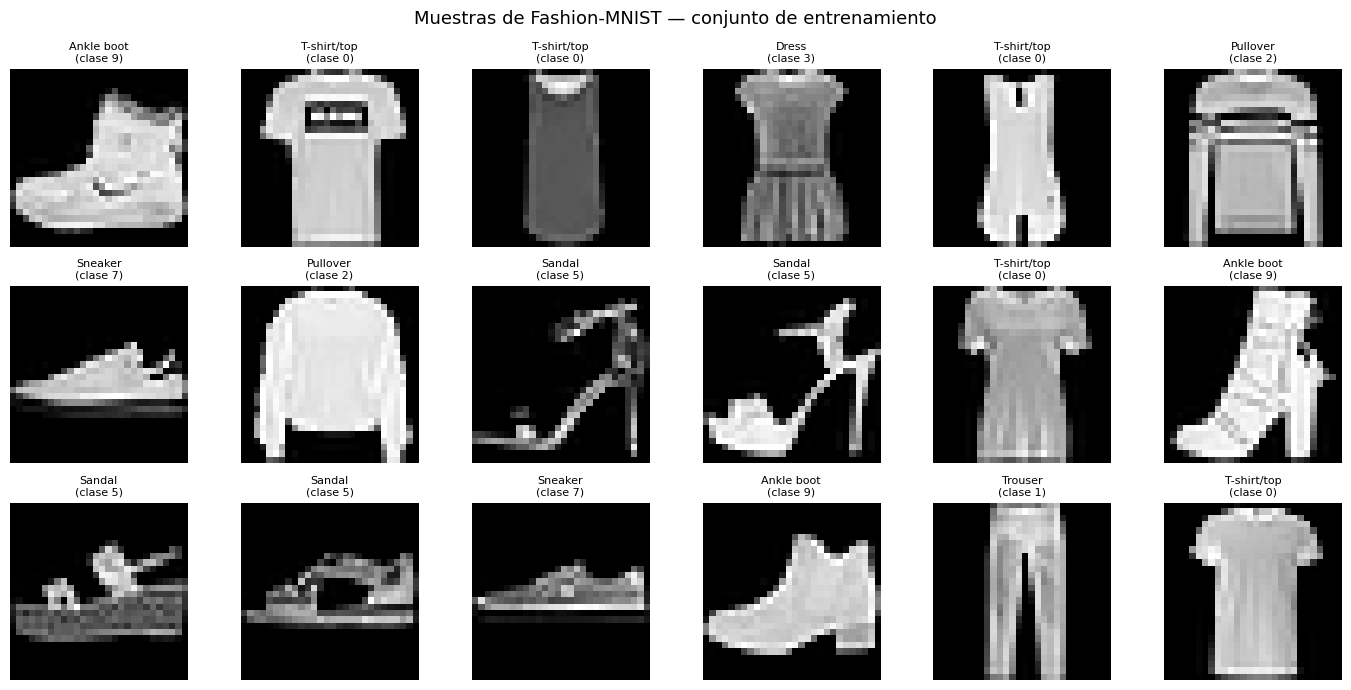

In [8]:
# Visualización de muestras del dataset
CLASS_NAMES = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

fig, axes = plt.subplots(3, 6, figsize=(14, 7))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i], cmap='gray')
    ax.set_title(f"{CLASS_NAMES[y_train[i]]}\n(clase {y_train[i]})", fontsize=8)
    ax.axis('off')
plt.suptitle("Muestras de Fashion-MNIST — conjunto de entrenamiento", fontsize=13)
plt.tight_layout()
plt.show()

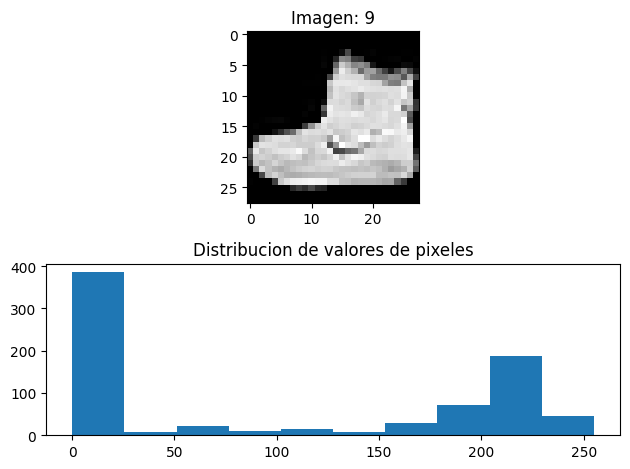

In [9]:
fig = plt.figure()
plt.subplot(2,1,1)
plt.imshow(X_train[0], cmap='gray', interpolation='none')
plt.title("Imagen: {}".format(y_train[0]))
plt.subplot(2,1,2)
plt.hist(X_train[0].reshape(784))
plt.title("Distribucion de valores de pixeles")
plt.tight_layout()
plt.show()

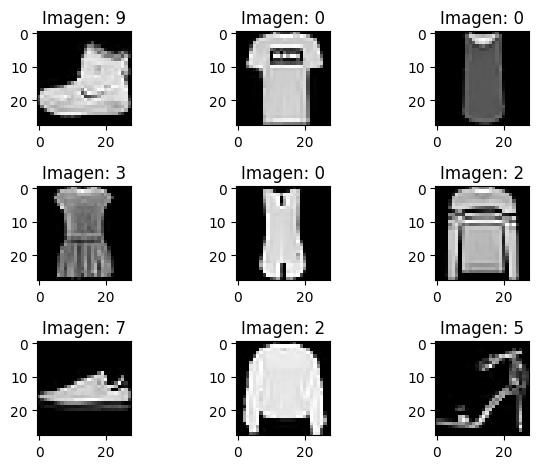

In [10]:
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.tight_layout()
    plt.imshow(X_train[i], cmap='gray', interpolation='none')
    plt.title("Imagen: {}".format(y_train[i]))

##Preprocesamiento para Red Neuronal Densa (ANN)

La red neuronal densa requiere vectores 1D como entrada. Cada imagen de 28×28 px se aplana a un vector de 784 valores.

**Transformaciones aplicadas:**
- **Normalización:** dividir por 255 para llevar los píxeles al rango [0, 1], acelerando la convergencia.
- **Reshape:** de (N, 28, 28) a (N, 784) para la capa `Dense` de entrada.

In [11]:
# Preprocesamiento para ANN
X_train_ann = X_train.reshape((60000, 784)).astype('float32') / 255.0
X_test_ann  = X_test.reshape((10000, 784)).astype('float32') / 255.0

print(f"Forma entrada ANN — train: {X_train_ann.shape}")
print(f"Forma entrada ANN — test:  {X_test_ann.shape}")
print(f"Rango de valores:          [{X_train_ann.min():.2f}, {X_train_ann.max():.2f}]")

Forma entrada ANN — train: (60000, 784)
Forma entrada ANN — test:  (10000, 784)
Rango de valores:          [0.00, 1.00]


### Diseño de la arquitectura ANN

Una red neuronal densa (fully connected) conecta cada neurona con todas las de la capa siguiente.

**Componentes identificados:**
- **Capas:** entrada (784), oculta 1 (512, ReLU), oculta 2 (256, ReLU), salida (10, Softmax)
- **Función de activación ReLU:** `max(0, x)` — introduce no-linealidad, evita el problema del gradiente evanescente
- **Función de activación Softmax:** convierte el vector de salida en probabilidades que suman 1
- **Función de pérdida:** `sparse_categorical_crossentropy` — mide el error en clasificación multiclase
- **Optimizador:** Adam — ajusta los pesos durante el entrenamiento
- **Regularización Dropout:** desactiva aleatoriamente un porcentaje de neuronas en cada paso, reduciendo el sobreajuste

---
## Lección 2: Deep Learning — Justificación de la arquitectura

**Objetivo:** Reconocer las principales arquitecturas, usos y frameworks de Deep Learning. Justificar la elección de CNN sobre ANN para clasificación de imágenes.

### ¿Por qué usar una CNN en lugar de una ANN densa?

| Característica | Red Densa (ANN) | Red Convolutiva (CNN) |
|---|---|---|
| **Entrada** | Vector 1D (784 valores aplanados) | Imagen 2D (28×28×1) — preserva estructura espacial |
| **Parámetros** | ~400.000 (Dense 784→512) | ~320 (Conv2D 32 filtros 3×3) |
| **Detección de patrones** | Patrones globales, sin localización | Patrones locales (bordes, texturas, formas) |
| **Invarianza traslacional** | No — un patrón en otro píxel es desconocido | Sí — el mismo filtro recorre toda la imagen |
| **Overfitting** | Mayor riesgo por alta cantidad de parámetros | Menor riesgo por compartición de pesos |
| **Aplicación ideal** | Datos tabulares, series de tiempo cortas | Imágenes, audio, series espaciales |

**Conclusión:** Para clasificar prendas de ropa, la CNN es la arquitectura óptima porque aprovecha la estructura espacial de las imágenes. Los filtros convolucionales aprenden a detectar bordes en las primeras capas y texturas/formas en capas más profundas, con una fracción de los parámetros de una red densa equivalente.

**Framework elegido:** Keras — API de alto nivel, ampliamente adoptada en la industria, con soporte para GPUs y excelente documentación.

##Lección 3

###Red ANN

In [12]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Semilla para reproducibilidad
tf.random.set_seed(42)
np.random.seed(42)

In [13]:
#Construcción de la red
model_ann = models.Sequential([
    # Capa de entrada + primera capa oculta
    layers.Dense(512, activation='relu', input_shape=(784,)),
    # Dropout: regularización — desactiva 20% de neuronas aleatoriamente
    layers.Dropout(0.2),
    # Segunda capa oculta
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.2),
    # Capa de salida: 10 clases con Softmax
    layers.Dense(10, activation='softmax')
], name='modelo_ann')

model_ann.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_ann.summary()

Model: "modelo_ann"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 535,818 (2.04 MB)

 Trainable params: 535,818 (2.04 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
# Entrenamiento de la ANN
print("Entrenando red neuronal densa (ANN)...")
history_ann = model_ann.fit(
    X_train_ann, y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

Entrenando red neuronal densa (ANN)...
Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.8031 - loss: 0.5465 - val_accuracy: 0.8539 - val_loss: 0.4084
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 11s 21ms/step - accuracy: 0.8548 - loss: 0.3954 - val_accuracy: 0.8654 - val_loss: 0.3654
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.8677 - loss: 0.3576 - val_accuracy: 0.8654 - val_loss: 0.3640
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.8763 - loss: 0.3358 - val_accuracy: 0.8617 - val_loss: 0.3684
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.8818 - loss: 0.3173 - val_accuracy: 0.8733 - val_loss: 0.3433
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.8867 - loss: 0.3040 - val_accuracy: 0.8728 - val_loss: 0.3411
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.8912 - loss: 0.2913 - val_accuracy: 0.8783 - val_loss: 0.3247
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step -

###Métricas

In [15]:
# Evaluación de la ANN
loss_ann, acc_ann = model_ann.evaluate(X_test_ann, y_test, verbose=0)
print(f"\n=== Métricas finales ANN ===")
print(f"Loss (test):     {loss_ann:.4f}")
print(f"Accuracy (test): {acc_ann:.4f} ({acc_ann*100:.2f}%)")


=== Métricas finales ANN ===
Loss (test):     0.3481
Accuracy (test): 0.8752 (87.52%)


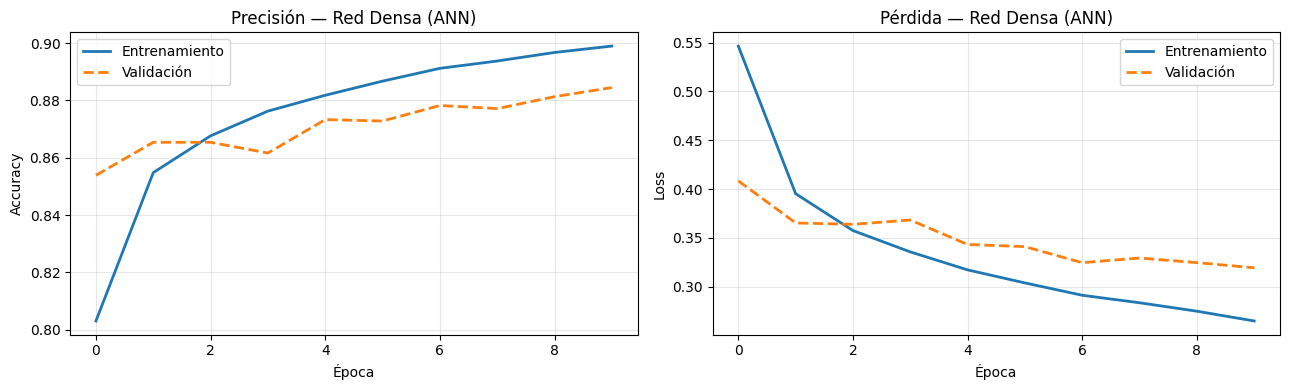

In [16]:
# Función para graficar el historial de entrenamiento
def plot_history(history, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

    # Precisión
    ax1.plot(history.history['accuracy'],     label='Entrenamiento', linewidth=2)
    ax1.plot(history.history['val_accuracy'], label='Validación',    linewidth=2, linestyle='--')
    ax1.set_title(f'Precisión — {title}')
    ax1.set_xlabel('Época')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(alpha=0.3)

    # Pérdida
    ax2.plot(history.history['loss'],     label='Entrenamiento', linewidth=2)
    ax2.plot(history.history['val_loss'], label='Validación',    linewidth=2, linestyle='--')
    ax2.set_title(f'Pérdida — {title}')
    ax2.set_xlabel('Época')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_history(history_ann, "Red Densa (ANN)")

In [17]:
# Reporte de clasificación detallado — ANN
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

y_pred_ann = np.argmax(model_ann.predict(X_test_ann, verbose=0), axis=1)

print("=== Reporte de clasificación — ANN ===")
print(classification_report(y_test, y_pred_ann, target_names=CLASS_NAMES))

=== Reporte de clasificación — ANN ===
              precision    recall  f1-score   support

 T-shirt/top       0.91      0.71      0.80      1000
     Trouser       1.00      0.96      0.98      1000
    Pullover       0.82      0.77      0.79      1000
       Dress       0.87      0.90      0.88      1000
        Coat       0.81      0.77      0.79      1000
      Sandal       0.98      0.96      0.97      1000
       Shirt       0.60      0.82      0.69      1000
     Sneaker       0.94      0.96      0.95      1000
         Bag       0.98      0.96      0.97      1000
  Ankle boot       0.96      0.95      0.96      1000

    accuracy                           0.88     10000
   macro avg       0.89      0.88      0.88     10000
weighted avg       0.89      0.88      0.88     10000



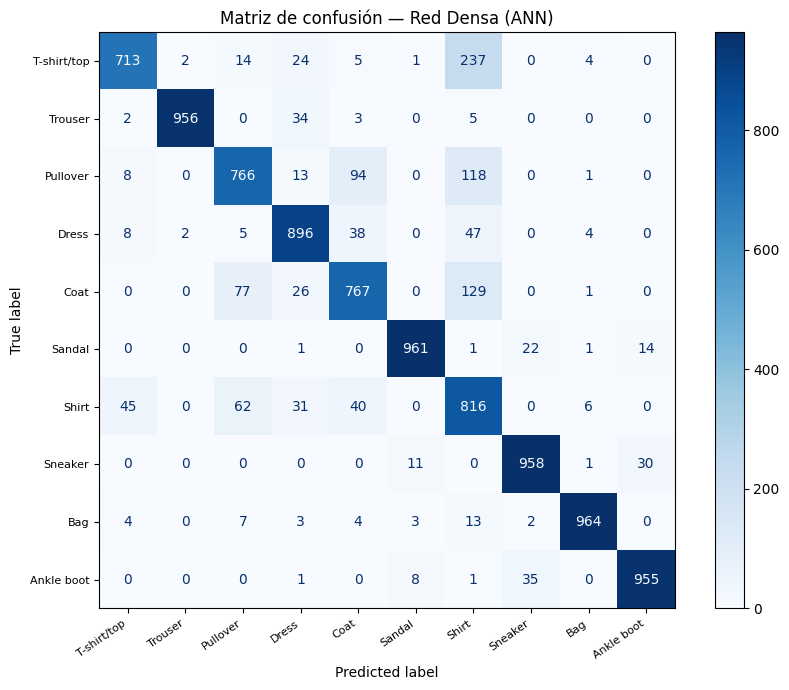

In [18]:
# Matriz de confusión — ANN
cm_ann = confusion_matrix(y_test, y_pred_ann)
disp   = ConfusionMatrixDisplay(confusion_matrix=cm_ann, display_labels=np.arange(10))

fig, ax = plt.subplots(figsize=(9, 7))
disp.plot(cmap='Blues', ax=ax, colorbar=True)
ax.set_title("Matriz de confusión — Red Densa (ANN)")
ax.set_xticklabels(CLASS_NAMES, rotation=35, ha='right', fontsize=8)
ax.set_yticklabels(CLASS_NAMES, fontsize=8)
plt.tight_layout()
plt.show()

##Lección 4

#### Preprocesamiento

Primero escalamos los datos, como los valores van de 0 a 255, basta solamente con dividir por 255, lo llevaremos de un shape (60000, 28, 28) lo transformaremos en un shape (60000, 28, 28, 1). Esto, porque así lo requiere keras:

In [19]:
# Preprocesamiento para CNN
X_train_cnn = X_train.reshape((60000, 28, 28, 1)).astype('float32') / 255.0
X_test_cnn  = X_test.reshape((10000, 28, 28, 1)).astype('float32') / 255.0

print(f"Forma entrada CNN — train: {X_train_cnn.shape}")
print(f"Forma entrada CNN — test:  {X_test_cnn.shape}")
print("Diferencia con ANN: la imagen conserva sus dimensiones 28×28 + canal")

Forma entrada CNN — train: (60000, 28, 28, 1)
Forma entrada CNN — test:  (10000, 28, 28, 1)
Diferencia con ANN: la imagen conserva sus dimensiones 28×28 + canal


#### Diseño de la Arquitectura de la Red

Arquitectura:


* Entrada: (28, 28, 1)
* Conv2D(32, 3×3, ReLU) → extrae 32 mapas de características (bordes básicos)
* Conv2D(32, 3×3, ReLU) → extrae 32 mapas de características (bordes básicos)
* MaxPooling2D(2×2) → reduce dimensiones a la mitad, retiene características dominantes
* Conv2D(64, 3×3, ReLU) → extrae 64 características más complejas (texturas, formas)
* MaxPooling2D(2×2) → segunda reducción dimensional
* Flatten()  → convierte los mapas 2D a vector 1D
* Dense(64, ReLU) → capa densa de integración
* Dropout(0.3) → regularización — evita sobreajuste
* Dense(10, Softmax) → capa de salida: probabilidad por clase

In [20]:
import tensorflow as tf
from tensorflow.keras import layers, models

In [21]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense,Conv2D,MaxPooling2D,Flatten,Dropout
from tensorflow.keras.optimizers import SGD, Adam
from tensorflow.keras.utils import plot_model

###Red CNN

In [22]:
# ============================================================
# MODELO CNN — Red Neuronal Convolutiva
# ============================================================


model_cnn = models.Sequential([
    # Bloque convolucional 1
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    # Bloque convolucional 2
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    # Clasificador
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
], name='modelo_cnn')

model_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_cnn.summary()

Model: "modelo_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
#from tensorflow.keras.utils import to_categorical
#y_train=to_categorical(y_train,10)

In [24]:
#y_test=to_categorical(y_test,10)

#### Entrenamiento del Modelo

In [25]:
print("Entrenando red neuronal convolutiva (CNN)...")
history_cnn = model_cnn.fit(
    X_train_cnn, y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

Entrenando red neuronal convolutiva (CNN)...
Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 41s 105ms/step - accuracy: 0.7435 - loss: 0.7063 - val_accuracy: 0.8458 - val_loss: 0.4379
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 39s 101ms/step - accuracy: 0.8332 - loss: 0.4549 - val_accuracy: 0.8650 - val_loss: 0.3778
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 41s 102ms/step - accuracy: 0.8551 - loss: 0.3962 - val_accuracy: 0.8733 - val_loss: 0.3397
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 41s 102ms/step - accuracy: 0.8694 - loss: 0.3598 - val_accuracy: 0.8852 - val_loss: 0.3088
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 38s 102ms/step - accuracy: 0.8797 - loss: 0.3338 - val_accuracy: 0.8880 - val_loss: 0.3031
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 37s 100ms/step - accuracy: 0.8864 - loss: 0.3133 - val_accuracy: 0.8949 - val_loss: 0.2848
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 44s 107ms/step - accuracy: 0.8925 - loss: 0.2936 - val_accuracy: 0.8969 - val_loss: 0.2826
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━

###Métricas

In [26]:
# Evaluación de la CNN en el conjunto de test
loss_cnn, acc_cnn = model_cnn.evaluate(X_test_cnn, y_test, verbose=0)
print(f"\n=== Métricas finales CNN ===")
print(f"Loss (test):     {loss_cnn:.4f}")
print(f"Accuracy (test): {acc_cnn:.4f} ({acc_cnn*100:.2f}%)")


=== Métricas finales CNN ===
Loss (test):     0.2876
Accuracy (test): 0.8967 (89.67%)


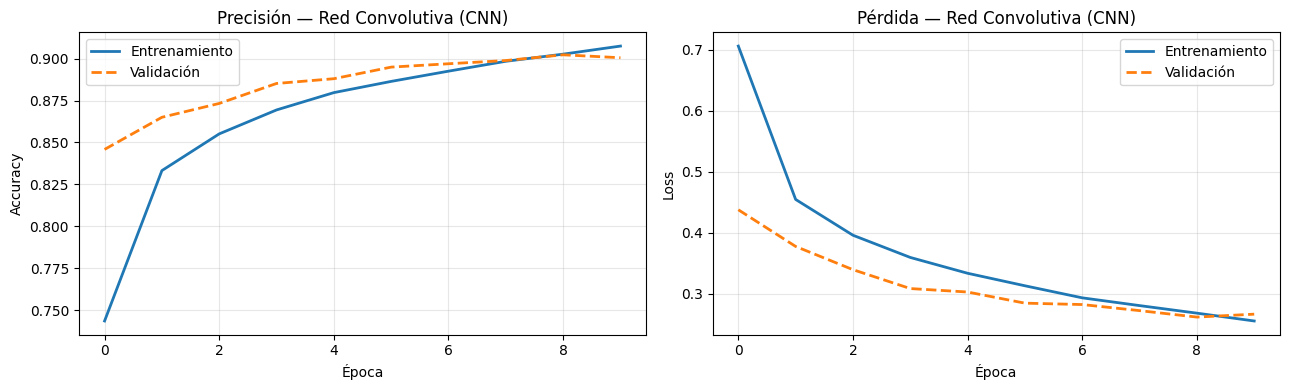

In [27]:
plot_history(history_cnn, "Red Convolutiva (CNN)")

In [28]:
# Reporte de clasificación detallado — CNN
y_pred_cnn = np.argmax(model_cnn.predict(X_test_cnn, verbose=0), axis=1)

print("=== Reporte de clasificación — CNN ===")
print(classification_report(y_test, y_pred_cnn, target_names=CLASS_NAMES))

=== Reporte de clasificación — CNN ===
              precision    recall  f1-score   support

 T-shirt/top       0.90      0.78      0.83      1000
     Trouser       1.00      0.97      0.99      1000
    Pullover       0.84      0.85      0.85      1000
       Dress       0.88      0.92      0.90      1000
        Coat       0.83      0.84      0.84      1000
      Sandal       0.95      0.99      0.97      1000
       Shirt       0.68      0.74      0.71      1000
     Sneaker       0.95      0.95      0.95      1000
         Bag       0.97      0.98      0.97      1000
  Ankle boot       0.98      0.95      0.96      1000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



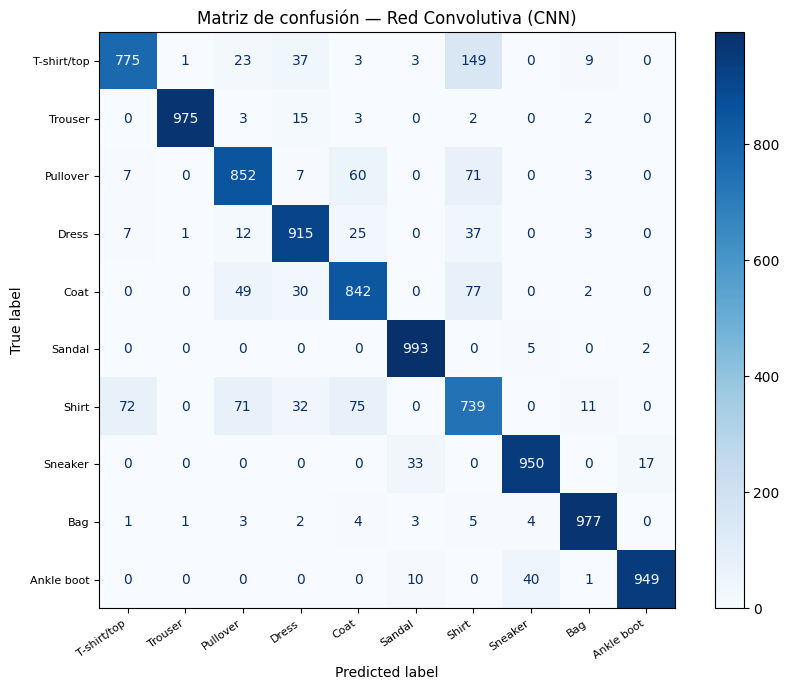

In [29]:
# Matriz de confusión — CNN
cm_cnn = confusion_matrix(y_test, y_pred_cnn)
disp   = ConfusionMatrixDisplay(confusion_matrix=cm_cnn, display_labels=np.arange(10))

fig, ax = plt.subplots(figsize=(9, 7))
disp.plot(cmap='Blues', ax=ax, colorbar=True)
ax.set_title("Matriz de confusión — Red Convolutiva (CNN)")
ax.set_xticklabels(CLASS_NAMES, rotation=35, ha='right', fontsize=8)
ax.set_yticklabels(CLASS_NAMES, fontsize=8)
plt.tight_layout()
plt.show()

### Comparación de desempeño: ANN vs CNN

A continuación se comparan las métricas principales de ambos modelos sobre el conjunto de test.

In [30]:
# Tabla comparativa
mejora = (acc_cnn - acc_ann) * 100

print("==========================================")
print("       COMPARACIÓN ANN vs CNN             ")
print("==========================================")
print(f" {'Modelo':<18} {'Loss':>8} {'Accuracy':>10}")
print("-" * 42)
print(f" {'Red Densa (ANN)':<18} {loss_ann:>8.4f} {acc_ann:>10.4f}")
print(f" {'Red CNN':<18} {loss_cnn:>8.4f} {acc_cnn:>10.4f}")
print("==========================================")
print(f" Mejora CNN sobre ANN: +{mejora:.2f} pp en accuracy")
print("==========================================")

       COMPARACIÓN ANN vs CNN             
 Modelo                 Loss   Accuracy
------------------------------------------
 Red Densa (ANN)      0.3481     0.8752
 Red CNN              0.2876     0.8967
 Mejora CNN sobre ANN: +2.15 pp en accuracy


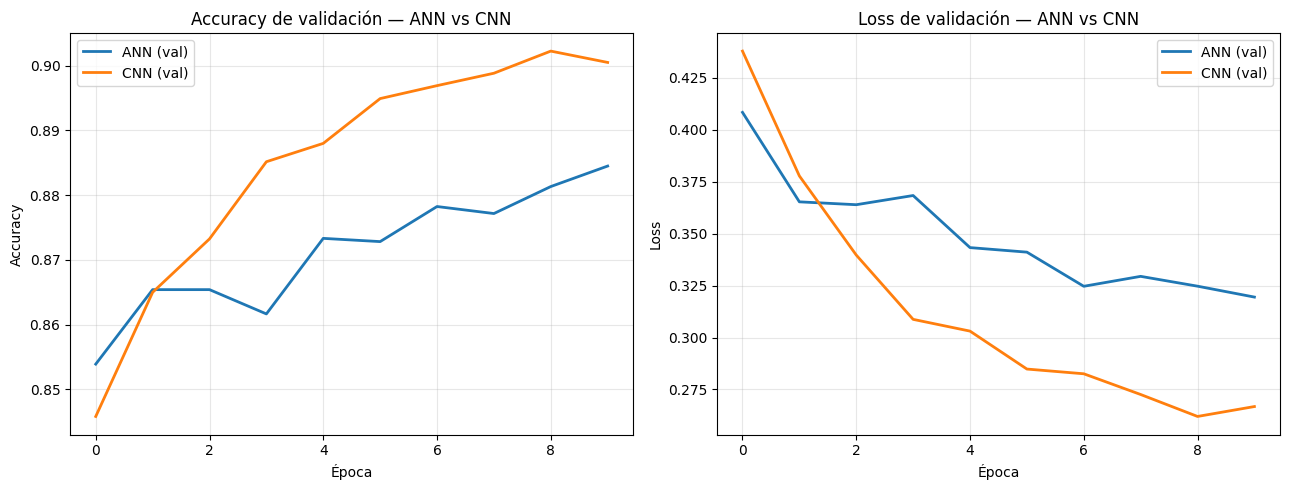

In [31]:
# Gráfico comparativo de curvas de entrenamiento
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Accuracy
axes[0].plot(history_ann.history['val_accuracy'], label='ANN (val)', linewidth=2)
axes[0].plot(history_cnn.history['val_accuracy'], label='CNN (val)', linewidth=2)
axes[0].set_title('Accuracy de validación — ANN vs CNN')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Loss
axes[1].plot(history_ann.history['val_loss'], label='ANN (val)', linewidth=2)
axes[1].plot(history_cnn.history['val_loss'], label='CNN (val)', linewidth=2)
axes[1].set_title('Loss de validación — ANN vs CNN')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Predicciones visuales sobre imágenes del conjunto de test

Visualización de predicciones del modelo CNN sobre muestras del conjunto de test, indicando si la predicción fue correcta o incorrecta.

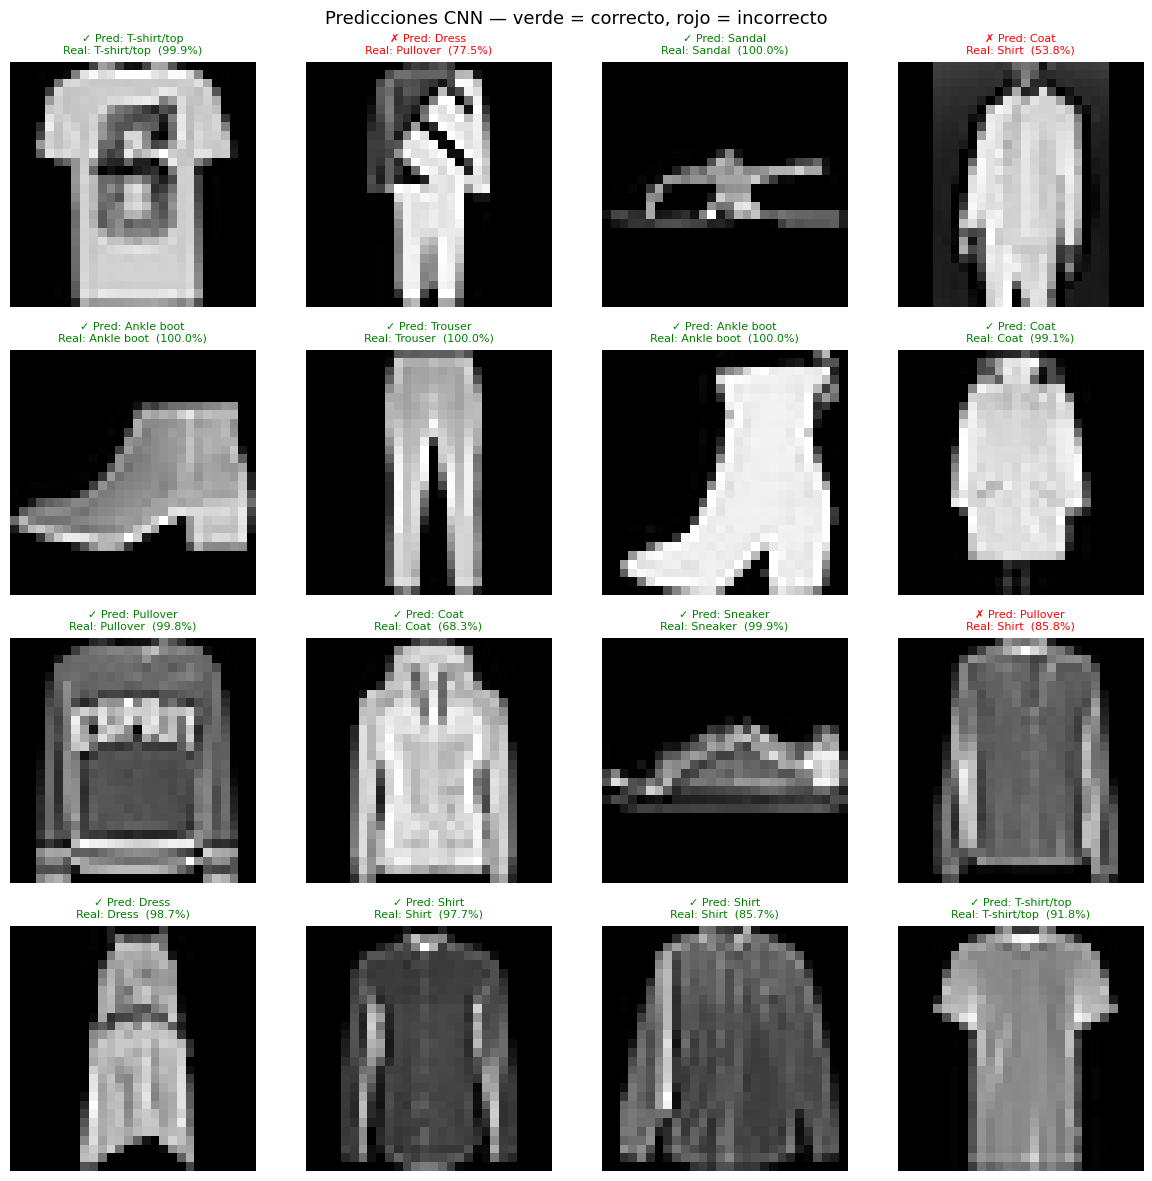

In [32]:
# Predicciones visuales — muestra aleatoria del conjunto de test
np.random.seed(7)
indices  = np.random.choice(len(X_test), 16, replace=False)
imagenes = X_test_cnn[indices]
labels   = y_test[indices]
probs    = model_cnn.predict(imagenes, verbose=0)
preds    = np.argmax(probs, axis=1)

fig, axes = plt.subplots(4, 4, figsize=(12, 12))
for i, ax in enumerate(axes.flat):
    ax.imshow(imagenes[i].reshape(28, 28), cmap='gray')
    color   = 'green' if preds[i] == labels[i] else 'red'
    correcto = '✓' if preds[i] == labels[i] else '✗'
    confianza = probs[i, preds[i]] * 100
    ax.set_title(
        f"{correcto} Pred: {CLASS_NAMES[preds[i]]}\n"
        f"Real: {CLASS_NAMES[labels[i]]}  ({confianza:.1f}%)",
        fontsize=8, color=color
    )
    ax.axis('off')
plt.suptitle("Predicciones CNN — verde = correcto, rojo = incorrecto", fontsize=13)
plt.tight_layout()
plt.show()

### Predicción sobre imágenes externas cargadas manualmente

La siguiente función permite cargar una imagen externa (JPG/PNG) y obtener la predicción del modelo CNN entrenado. La imagen se convierte a escala de grises y se redimensiona a 28×28 px.

In [33]:
from tensorflow.keras.preprocessing import image as keras_image

def predecir_imagen_externa(ruta_imagen, modelo=model_cnn, class_names=CLASS_NAMES):
    """
    Carga una imagen externa, la preprocesa al formato Fashion-MNIST
    y devuelve la predicción del modelo.

    Parámetros:
        ruta_imagen : str  — ruta al archivo de imagen (JPG, PNG, etc.)
        modelo      : Model — modelo Keras entrenado (por defecto: model_cnn)
        class_names : list — lista con los nombres de las clases
    """
    # Cargar en escala de grises y redimensionar a 28×28
    img = keras_image.load_img(ruta_imagen, color_mode='grayscale', target_size=(28, 28))
    img_array = keras_image.img_to_array(img)
    img_array = img_array / 255.0
    img_array = img_array.reshape((1, 28, 28, 1))   # batch dimension

    # Predicción
    predicciones  = modelo.predict(img_array, verbose=0)
    clase_predicha = np.argmax(predicciones[0])
    probabilidad   = np.max(predicciones[0])

    # Visualización
    fig, axes = plt.subplots(1, 2, figsize=(9, 4))

    axes[0].imshow(img, cmap='gray')
    axes[0].set_title(
        f"Predicción: {class_names[clase_predicha]}\n"
        f"Confianza: {probabilidad:.2%}",
        fontsize=11
    )
    axes[0].axis('off')

    # Top-5 probabilidades
    top5_idx   = np.argsort(predicciones[0])[::-1][:5]
    top5_probs = predicciones[0][top5_idx]
    top5_names = [class_names[i] for i in top5_idx]
    colores    = ['steelblue' if i != clase_predicha else 'coral' for i in top5_idx]

    axes[1].barh(top5_names[::-1], top5_probs[::-1], color=colores[::-1])
    axes[1].set_xlim(0, 1)
    axes[1].set_xlabel('Probabilidad')
    axes[1].set_title('Top-5 probabilidades')
    for i, (prob, name) in enumerate(zip(top5_probs[::-1], top5_names[::-1])):
        axes[1].text(prob + 0.01, i, f'{prob:.2%}', va='center', fontsize=9)

    plt.suptitle(f"Análisis de predicción — {class_names[clase_predicha]}", fontsize=13)
    plt.tight_layout()
    plt.show()

    print(f"Clase predicha:  {clase_predicha} — {class_names[clase_predicha]}")
    print(f"Probabilidad:    {probabilidad:.4f}")

    return clase_predicha, probabilidad

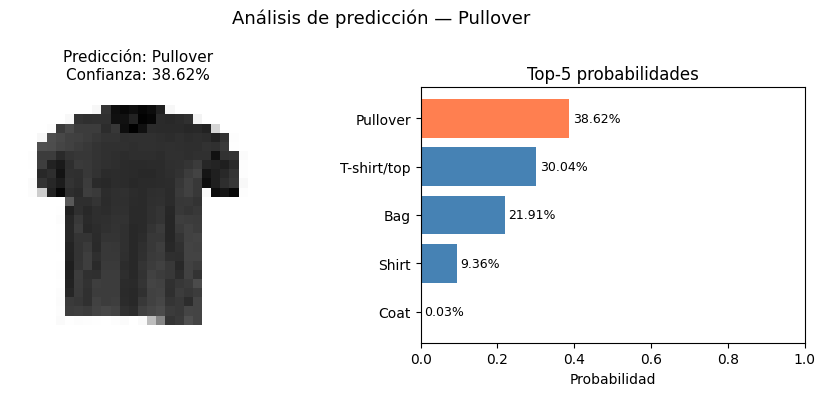

Clase predicha:  2 — Pullover
Probabilidad:    0.3862


(np.int64(2), np.float32(0.38617274))

In [41]:
# Se debe reemplazar la ruta con la imagen que se busca predecir
# -------------------------------------------------------
predecir_imagen_externa('polera.jpeg')

#### Métricas de Evaluación

In [35]:
from sklearn.metrics import accuracy_score

In [36]:
y_pred = model_cnn.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step


In [37]:
y_pred

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.99999994],
       [0.        , 0.        , 0.99999994, ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.99999994, 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.99999994,
        0.        ],
       [0.        , 0.99999994, 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]], dtype=float32)

In [38]:
y_pred_label=np.argmax(y_pred,axis=1)

In [39]:
y_pred_label

array([9, 2, 1, ..., 8, 1, 5])

In [40]:
y_test

array([9, 2, 1, ..., 8, 1, 5], dtype=uint8)